# TODO

jobs STARTED IN OR AFTER year of graduation

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
from datetime import datetime
import networkx as nx
import re
from plotnine import ggplot, aes
import plotnine as p9
from wordcloud import WordCloud

plt.style.use("ggplot")

output = "output/csv/"
input = "input/"
figures = "figures/"
uk = ["England", "Scotland", "Wales", "Northern Ireland"]

papers = pd.read_excel(f"{input}students.xlsx", sheet_name="Papers").drop_duplicates(
    subset=["DOI"], keep="first"
)
students = pd.read_excel(f"{input}students.xlsx", sheet_name="Students")
jobs = pd.read_excel(f"{input}students.xlsx", sheet_name="Jobs")

students = students[students.Year != 2020]

to_exclude = [0, "0", np.nan, "nan", "None", "none", "", "Not Found", "Error"]

## Papers and publications
### Graduates' publications since starting with the DTC

A large proportion of the publication history was collected prior to my joining, using (at least mostly, I presume) methodology as outlined by Hector in his onboarding. This entailed looking up the graduate's name on Scopus and manually exporting their publication history as a spreadsheet which was then manually appended onto the master spreadsheet.

This has the advantage of accuracy (see discussion of manual LinkedIn scraping) but is time consuming, so I have opted to use an API instead. I have used [OpenAlex](https://openalex.org/): this is open source (unlike alternatives such as [SemanticScholar](https://www.semanticscholar.org/), which is AI-driven and I will use to verify, now that they responded to me!, and Elsevier's own proprietary API) and free (another win over Elsevier).

Methodology:
1. API search for each name in the alumni database. Retrieve the corresponding ORCID for the closest match, as well as said closest match's listed name.
2. Using these ORCIDs, perform an API search to find the corresponding OpenAlex 'author object' and its associated papers.
3. Where the name listed in the alumni database doesn't match the name corresponding to the ORCID found in the API search, manually check the ORCID/OpenAlex record for the person found. In some cases it's the same person under a different name; where this is NOT the case, exclude all papers with this ORCID.

I also performed random checks on the ORCIDs where there was a name match (ie those that were not auto-flagged as suspicious during step 3) to check that they are correct.

This code can be rerun any time, including with corrected ORCIDs need be.

To start with, we can look at how many papers each alumnus published. Of course this is a metric in which there will be a few extreme outlisers.

### How many papers did students publish?

Some students have published a LOT of papers. Descriptive statistics of how many papers each students published are down below.

Descriptive statistics of papers per student


,papers
count,889.000000
mean,17.327334
std,18.749767
min,1.000000
25%,5.000000
50%,13.000000
75%,23.000000
max,202.000000


We will threshold at two standard deviations above the mean: 54.82686836153546


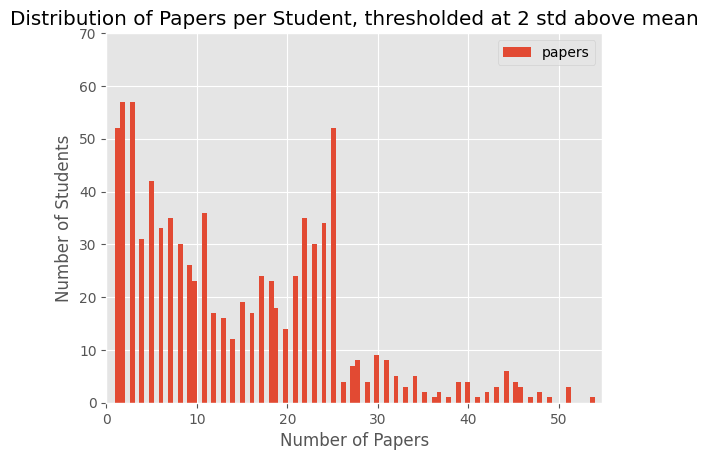

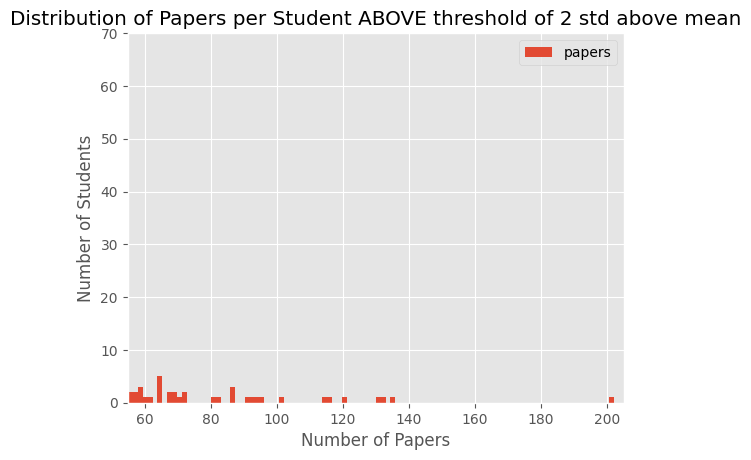

In [25]:
paper_counts = papers["Name"].value_counts().reset_index()
paper_counts.columns = ["Name", "papers"]
paper_counts = paper_counts.sort_values("papers", ascending=False)
paper_counts["papers"] = paper_counts["papers"].astype(float)

print("Descriptive statistics of papers per student")
desc = paper_counts["papers"].describe().to_frame()
display(desc)

mn = desc.loc["mean", "papers"]
std = desc.loc["std", "papers"]

thresh = mn + 2 * std
print(f"We will threshold at two standard deviations above the mean: {thresh}")

paper_counts[paper_counts.papers < thresh].plot(kind="hist", bins=100)
plt.title("Distribution of Papers per Student, thresholded at 2 std above mean")
plt.xlabel("Number of Papers")
plt.ylabel("Number of Students")
plt.ylim(0, 70)
plt.xlim(0, thresh)
plt.savefig(f"{figures}papers_per_student_hist.png")
plt.show()

paper_counts[paper_counts.papers > thresh].plot(kind="hist", bins=100)
plt.title("Distribution of Papers per Student ABOVE threshold of 2 std above mean")
plt.xlabel("Number of Papers")
plt.ylabel("Number of Students")
plt.ylim(0, 70)
plt.xlim(thresh, 205)
plt.savefig(f"{figures}papers_per_student_hist.png")
plt.show()

51
Descriptive statistics of papers/yr per student


,papers_time
count,838.000000
mean,1.504909
std,1.221574
min,0.043478
25%,0.505435
50%,1.275253
75%,2.200000
max,9.181818


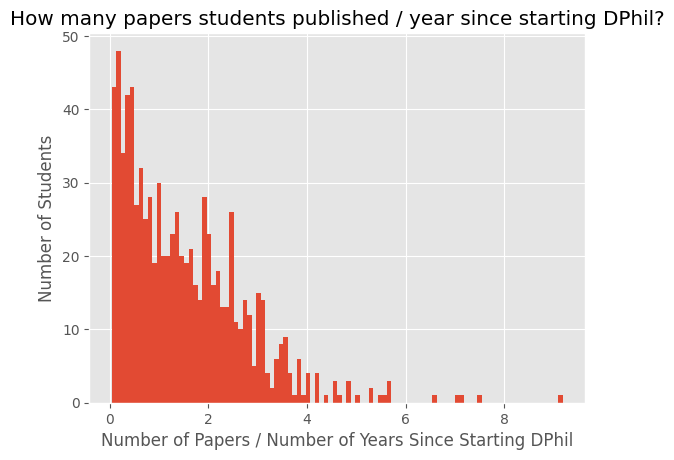

In [26]:
# numer of papers / number of years since starting
missing_names = []
current_year = datetime.now().year
num_papers_stand = papers["Name"].value_counts().reset_index()
num_papers_stand["Year"] = None
num_papers_stand["yr_since"] = None
for i, row in num_papers_stand.iterrows():
    name = row["Name"]
    try:
        year = students.loc[students["Name"] == name, "Year"].values[0]
        
        num_papers_stand.loc[i, "Year"] = year
        num_papers_stand.loc[i, "yr_since"] = current_year - year
    except IndexError:
        missing_names.append(name)
print(len(missing_names))
num_papers_stand = num_papers_stand.loc[num_papers_stand["Year"] != 0]
num_papers_stand["papers_time"] = (
    num_papers_stand["count"] / num_papers_stand["yr_since"]
)

print("Descriptive statistics of papers/yr per student")
num_papers_stand["papers_time"] = num_papers_stand["papers_time"].astype(float)
desc = num_papers_stand["papers_time"].describe().to_frame()
display(desc)

num_papers_stand["papers_time"].plot(kind="hist", bins=100)
plt.title("How many papers students published / year since starting DPhil?")
plt.xlabel("Number of Papers / Number of Years Since Starting DPhil")
plt.ylabel("Number of Students")
# plt.ylim(0, 120)
plt.show()

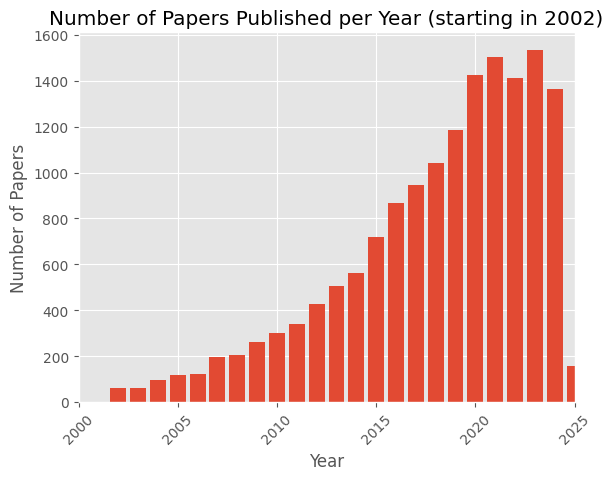

In [27]:
# bar chart of publication year
papers["Year"] = papers["Year"].astype(float)
# papers['years'] = papers['years'].astype(int)
papers_per_year = papers["Year"].value_counts().reset_index()
papers_per_year.columns = ["Year", "papers"]
papers_per_year = papers_per_year.sort_values("Year")
plt.bar(papers_per_year["Year"], papers_per_year["papers"])
# andgle the x-axis labels
plt.xticks(rotation=45)
plt.title("Number of Papers Published per Year (starting in 2002)")
plt.xlim(2000, 2025)
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.savefig(f"{figures}papers_per_year.png")
plt.show()

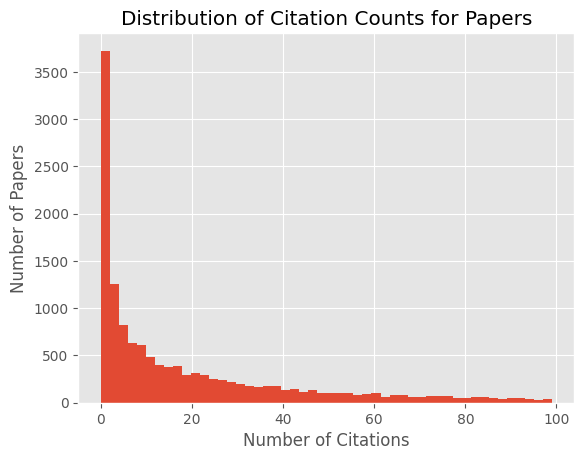

In [28]:
# histogram of citation count
papers["Citation Count"] = papers["Citation Count"].astype(float)
citation_counts = papers[papers["Citation Count"] < 100]
# .value_counts().reset_index()
citation_counts["Citation Count"].plot(kind="hist", bins=50)
plt.title("Distribution of Citation Counts for Papers")
plt.xlabel("Number of Citations")
plt.ylabel("Number of Papers")
plt.show()

/var/folders/5z/qyx2lwtj6_98flms8h5p09q40000gn/T/ipykernel_41324/1845696349.py:13: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3.6666666666666665' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.



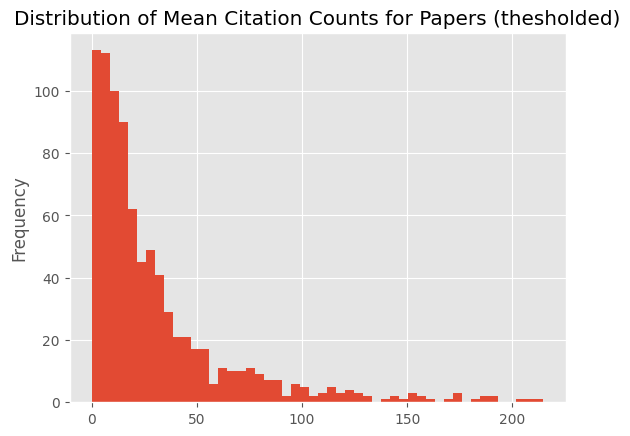

In [29]:
# distribution of mean citation count per paper for each student
citation_counts = pd.DataFrame({"Name": papers.Name.unique()})
citation_counts['Citation Count'] = 0
citation_counts["papers"] = 0
citation_counts["mean_citation"] = 0
for i, row in citation_counts.iterrows():
    name = row["Name"]
    n_papers = papers[papers.Name == name].shape[0]
    citations = papers[papers.Name == name]["Citation Count"].sum()
    citation_counts.loc[i, "papers"] = n_papers
    citation_counts.loc[i, "Citation Count"] = citations
    if n_papers > 0:
        citation_counts.loc[i, "mean_citation"] = citations / n_papers
    else:
        citation_counts.loc[i, "mean_citation"] = 0
citation_counts = citation_counts[citation_counts["papers"] > 0]
citation_counts = citation_counts[citation_counts["Citation Count"] > 0]

mean = citation_counts["mean_citation"].mean()
std = citation_counts["mean_citation"].std()
citation_counts = citation_counts[citation_counts["mean_citation"] < mean + 2 * std]

citation_counts["mean_citation"].plot(kind="hist", bins=50)
    
plt.title("Distribution of Mean Citation Counts for Papers (thesholded)")
plt.show()

Index(['Name', 'DOI', 'Title', 'Journal', 'Year', 'Citation Count', 'orcid',
       'i10', 'h_index'],
      dtype='object')


/var/folders/5z/qyx2lwtj6_98flms8h5p09q40000gn/T/ipykernel_41324/3534063448.py:4: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



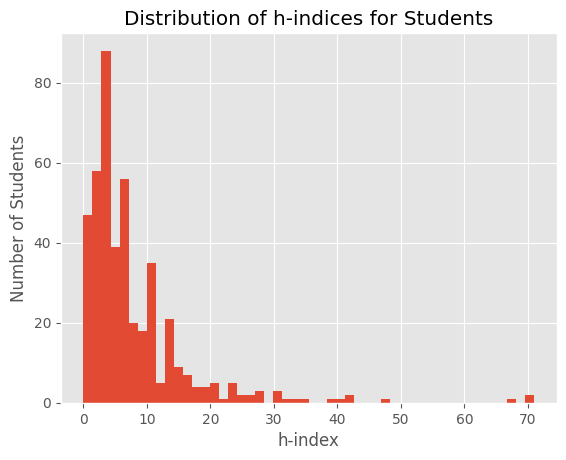

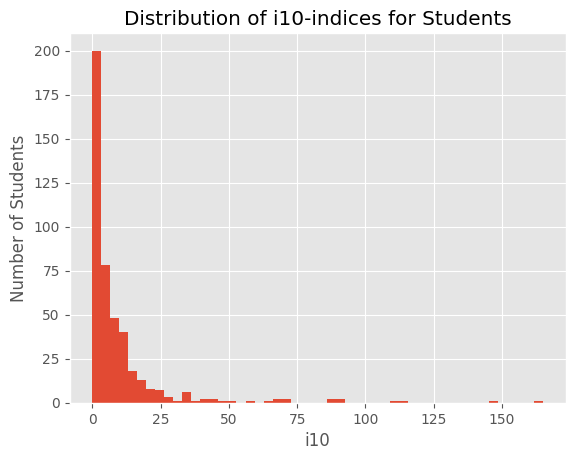

In [30]:
# distribution of h- and i-10 indices
print(papers.columns)
indices = papers.drop_duplicates(subset=["Name", "h_index", "i10"], keep="first")
indices = indices.replace({"Error": np.nan, "Not Found": np.nan})
indices["h_index"] = indices["h_index"].astype(float)
indices["i10"] = indices["i10"].astype(float)
indices["h_index"].plot(kind="hist", bins=50)
plt.title("Distribution of h-indices for Students")
plt.xlabel("h-index")
plt.ylabel("Number of Students")
plt.show()

indices["i10"].plot(kind="hist", bins=50)
plt.title("Distribution of i10-indices for Students")
plt.xlabel("i10")
plt.ylabel("Number of Students")
plt.show()


### Top employers

In [32]:
top_pharma = [
    "astrazeneca",
    "roche",
    "gsk",
    "novartis",
]

employers = jobs_since[jobs_since.Company.notna()]
employers.Company = employers.Company.str.lower()
in_top_pharma = employers[employers.Company.isin(top_pharma)]
in_top_pharma.to_csv('output/csv/pharma_graduates.csv')
print(in_top_pharma.shape)
print(in_top_pharma.Name.nunique())

(129, 17)
89


/var/folders/5z/qyx2lwtj6_98flms8h5p09q40000gn/T/ipykernel_41324/3186761556.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

